<a href="https://colab.research.google.com/github/praiseandrews/Data-Science-Learning/blob/main/06_House_Price_Prediction_Real/house_price_prediction_real.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape:
(545, 13)

First 5 Rows:
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  

Missing Values:
price               0
area                

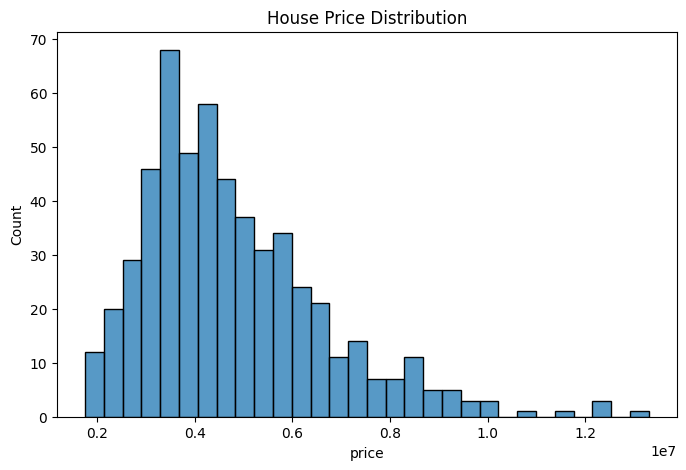

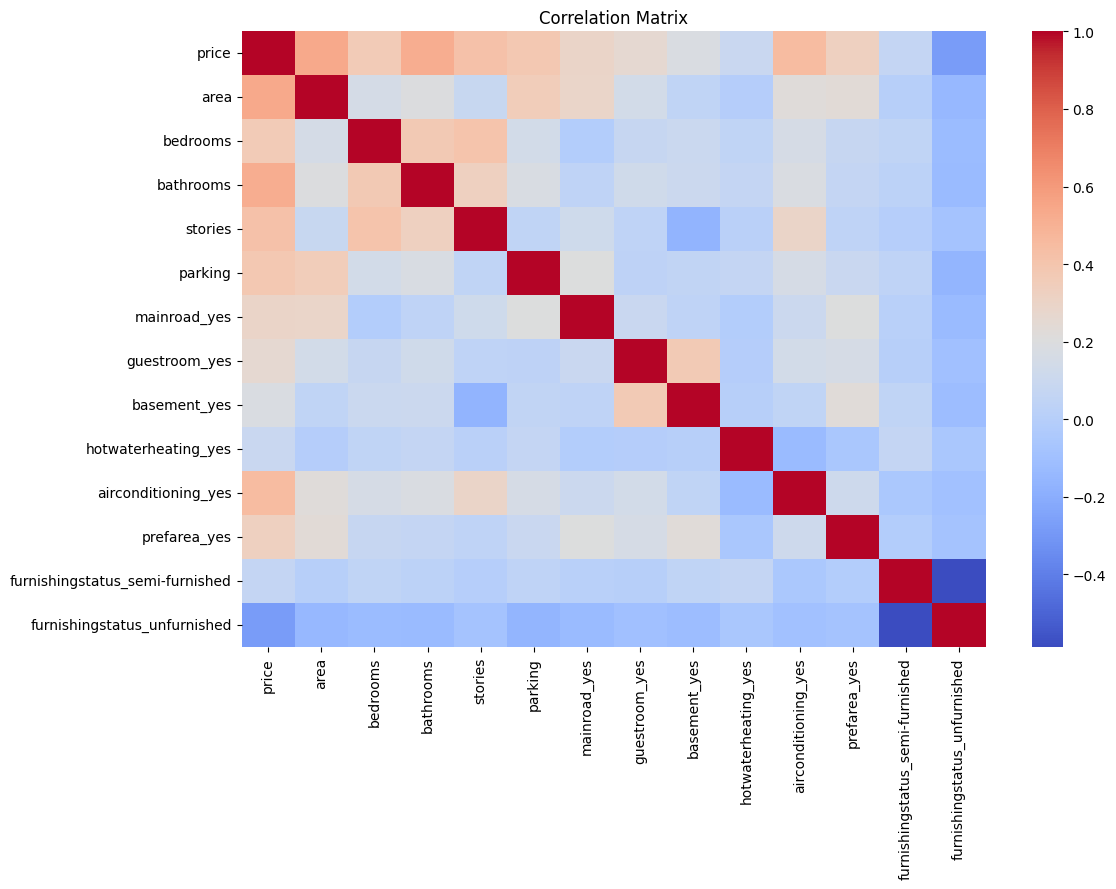


Model Performance
MAE: 970043.4039201636
R2 Score: 0.6529242642153184


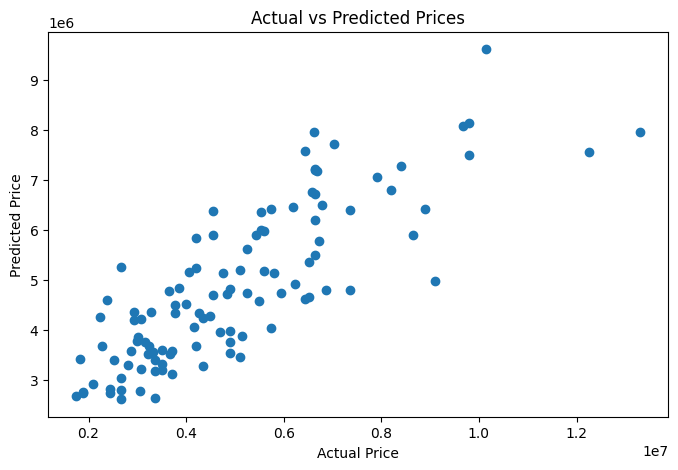


Model Saved Successfully!


In [1]:
# =====================================
# House Price Prediction - Real Dataset
# =====================================

# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# =====================================
# Load Dataset
# =====================================

df = pd.read_csv("/content/Housing.csv")

print("Dataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())

# =====================================
# Data Cleaning
# =====================================

print("\nMissing Values:")
print(df.isnull().sum())

# Convert categorical columns to numbers

categorical_cols = df.select_dtypes(include="object").columns

df = pd.get_dummies(df,
                    columns=categorical_cols,
                    drop_first=True)

# =====================================
# Exploratory Data Analysis (EDA)
# =====================================

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

# Price Distribution

plt.figure(figsize=(8,5))
sns.histplot(df["price"], bins=30)
plt.title("House Price Distribution")
plt.show()

# =====================================
# Correlation Analysis
# =====================================

correlation = df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(correlation,
            cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# =====================================
# Feature Selection
# =====================================

X = df.drop("price", axis=1)

y = df["price"]

# =====================================
# Train-Test Split
# =====================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =====================================
# Model Training
# =====================================

model = LinearRegression()

model.fit(X_train, y_train)

# =====================================
# Prediction
# =====================================

y_pred = model.predict(X_test)

# =====================================
# Evaluation
# =====================================

mae = mean_absolute_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("\nModel Performance")
print("MAE:", mae)
print("R2 Score:", r2)

# =====================================
# Actual vs Predicted
# =====================================

plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Prices")

plt.show()

# =====================================
# Save Model
# =====================================

import joblib

joblib.dump(model,
            "house_price_real_model.pkl")

print("\nModel Saved Successfully!")